# 23a — Fisher uncertainties for the exp6 `trial_07` model on the 14 real experiments

**Series 23 opener.** The model under study is the **best KDE-based model on the real data**:
the AG-HYPOPT **experiment_6 `trial_07`** score design (the exp5 winning schedule + the exp6 winner
`sigma_weight 0.8649`, `h_f_scale 4.0`, `h_s_scale 3.6745`, `gamma_rel_cap 0.10736`), i.e. the exact
series-21 μ mechanism (Anuar's `loglik_mean` reward, `sigma_prop` score, **no clip, no clamps**,
init `0.5 x truth`, `n_runs=100`, `n_iter=30`).

**Why KDE.** Fisher/Cramér-Rao needs a likelihood. The 2-D `(FWHM, sigma_fit)` **KDE** is our likelihood;
the exp8 alternative losses (Wasserstein, CvM, energy, MMD) are discrepancies and have no CRB. So the
KDE-only model is the right base for an uncertainty analysis.

**What this notebook does.** For **all 14 real experiments**:
1. runs the frozen optimisation (deterministic), records the full path + per-step simulated cloud;
2. at the optimum computes the **Fisher information of the KDE likelihood** and the CRB uncertainties
   `sigma_mu`, `sigma_gamma` (and their correlation) under the **existing convention** (the per-scan
   normalisation `J = sum_i s_i s_i^T / N`) **and** the dataset correction:
   - **A — per-scan**: the historic convention (the uncertainty of a *single* scan);
   - **B — dataset**: `sigma_data = sigma_single / sqrt(n_target)` — the CRB for the estimate from the
     whole experiment (undo the `/N`).

**Not touched.** No change to `src/` or to any previous notebook; this notebook copies the exp6 helpers
it needs. Figures render **inline only** (no savefig); executed **in place**.

## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per experiment: the **(mu, gamma) parameter path** (left) and the
  **generated (FWHM, sigma_fit) cloud at that step** (right) against the real data. Experiment dropdown +
  play button / slider over the iteration.
- **FIG 2 — the uncertainty report: μ on top, γ underneath** (one panel each, `hat/true` vs transmission
  with the CRB whiskers); the **hue is the laser power** (1nW | 3nW).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration (per power).
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

In [1]:
# ============================================================
# 23a — imports (repo bootstrap like the 22-series)
# ============================================================
import math, os, sys, time, json
from contextlib import nullcontext
import numpy as np
import torch
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')
print('Imports OK | plotly', plotly.__version__, '| repo', REPO_ROOT)


Imports OK | plotly 7.1.0 | repo /home/pukky/.openclaw/workspace/qm-ml


In [2]:
# ============================================================
# 23a — EXPERIMENTS (14 real; true values from Gregor's fits)
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
POWERS = ['1nW', '3nW']
TRANS  = ['05', '10', '20', '40', '60', '80', '100']
print(len(EXPERIMENTS), 'experiments')


14 experiments


In [3]:
# ============================================================
# 23a CONFIG — FROZEN experiment_6 trial_07 model + the Fisher knobs
# ============================================================
CFG = dict(
    n_runs=100, n_iter=30,                       # series-21/exp5/6 protocol
    # FROZEN schedule = experiment_5 winning trial (trial_21)
    lr_mu=0.1669, mu_anneal=0.3455, lr_gamma=0.4716, gamma_anneal=0.4723,
    sigma_ref=10.0, clip=float('inf'),           # no gradient clipping (21i)
    # FROZEN experiment_6 winner (trial_07)
    sigma_weight=0.8648862719598797,             # sigma-channel damping
    gamma_rel_cap=0.10735617789825944,           # relative gamma trust region
    h_f_scale=4.0, h_s_scale=3.674548492934102,  # inflated Scott bandwidths
    h_s_min=0.05,
)
H_REF = 1.0            # z-form gamma-score reference (optimizer only)
SEED  = 42             # per-step noise seed base (deterministic)
REAL_CSV = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

# ---- Fisher knobs ----
M_FINAL          = 500     # simulated scans for the Fisher estimate (per seed)
FISHER_SEEDS     = 5       # independent seeds averaged (as 12d)
FISHER_BASE_SEED = 7000

OUT_JSON = os.path.join(REPO_ROOT, 'data', 'processed', '23a_fisher_exp6_trial07.json')

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    CFG['n_runs'], CFG['n_iter'] = 20, 4
    EXPERIMENTS = EXPERIMENTS[4:5]
    M_FINAL, FISHER_SEEDS = 40, 1
print('config: %s | M_FINAL=%d, seeds=%d | SMOKE=%s' % (CFG, M_FINAL, FISHER_SEEDS, SMOKE))


config: {'n_runs': 100, 'n_iter': 30, 'lr_mu': 0.1669, 'mu_anneal': 0.3455, 'lr_gamma': 0.4716, 'gamma_anneal': 0.4723, 'sigma_ref': 10.0, 'clip': inf, 'sigma_weight': 0.8648862719598797, 'gamma_rel_cap': 0.10735617789825944, 'h_f_scale': 4.0, 'h_s_scale': 3.674548492934102, 'h_s_min': 0.05} | M_FINAL=500, seeds=5 | SMOKE=False


In [4]:
# ============================================================
# 23a — helpers (verbatim from experiment_6/ag_hypopt.py, plus a gamma_scale switch)
# ============================================================
GAMMA_SCALE = True     # optimizer uses the z-form gamma-score; the Fisher sets this False

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, cfg):
    '''2-D KDE log-likelihood pieces + per-DATA-POINT scores (as exp5/6).'''
    sw = float(cfg.get('sigma_weight', 1.0))
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + sw * (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + sw * (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def _load_real_target(exp):
    '''Real measured target for `exp` (15-series convention): raw*1000 -> MHz, keep err/fwhm < 10.'''
    import pandas as pd
    power_nW = int(str(exp['power']).replace('nW', ''))
    trans = int(str(exp['name']).split('Trans')[-1])
    df = pd.read_csv(REAL_CSV)
    sub = df[(df['power_nW'] == power_nW) & (df['transmission'] == trans)]
    f = sub['fwhm'].to_numpy(dtype=float) * 1000.0
    e = sub['fit_error'].to_numpy(dtype=float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        filt = ok & ((e / f) < 10.0)
    return (torch.tensor(f[filt], dtype=torch.float32), torch.tensor(e[filt], dtype=torch.float32))

def _bandwidths(target_f, target_s, h_f_scale, h_s_scale, h_s_min):
    '''Scott-from-target, scaled (FIXED w.r.t. mu,gamma -> a clean likelihood).'''
    scott = len(target_f) ** (-1.0 / 6.0)
    H_F = h_f_scale * float(target_f.std()) * scott
    H_S = max(h_s_scale * float(target_s.std()) * scott, h_s_min)
    return H_F, H_S

def _sims(pool, mu, sigma_prop, lam, gamma, n_runs, seed):
    rng = np.random.default_rng(seed)
    tasks, ns = [], []
    for _ in range(n_runs):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    return (torch.tensor([r[0] for r in res], dtype=torch.float32),
            torch.tensor([r[1] for r in res], dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor([r[2] for r in res], dtype=torch.float32),
            torch.tensor([r[3] for r in res], dtype=torch.float32))

def _fisher_at(pool, mu, gamma, sigma_prop, lam, target_f, target_s, H_F, H_S, cfg):
    '''Fisher of the KDE likelihood at (mu,gamma): per-scan J and the data-scaled J.
       Returns dict with sigma_mu/sigma_gamma under the per-scan normalisation and the
       dataset correction sigma/sqrt(N).'''
    global GAMMA_SCALE
    gs = GAMMA_SCALE; GAMMA_SCALE = False          # Fisher uses the RAW likelihood chain
    N = int(len(target_f))
    Js = []
    try:
        for s_i in range(FISHER_SEEDS):
            ft, si_t, nt, dg_t, ds_t = _sims(pool, mu, sigma_prop, lam, gamma, M_FINAL, FISHER_BASE_SEED + s_i)
            s_mu, s_gamma, _, _, _ = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                 target_f, target_s, H_F, H_S, mu, sigma_prop, cfg)
            s = torch.stack([s_mu, s_gamma], dim=1)
            Js.append(s.T @ s / N)                 # the EXISTING convention (per-scan)
    finally:
        GAMMA_SCALE = gs
    J_single = torch.stack(Js).mean(dim=0)
    inv_single = torch.linalg.inv(J_single + 1e-12 * torch.eye(2))
    inv_data = inv_single / N                      # dataset CRB = (N*J)^-1
    out = dict(N=N, J=J_single.tolist(),
               sig_mu_single=float(math.sqrt(inv_single[0, 0])),
               sig_g_single=float(math.sqrt(inv_single[1, 1])),
               corr_single=float(inv_single[0, 1] / math.sqrt(inv_single[0, 0] * inv_single[1, 1])),
               sig_mu_data=float(math.sqrt(inv_data[0, 0])),
               sig_g_data=float(math.sqrt(inv_data[1, 1])),
               corr_data=float(inv_data[0, 1] / math.sqrt(inv_data[0, 0] * inv_data[1, 1])))
    return out

print('helpers ready')


helpers ready


In [5]:
# ============================================================
# 23a — one experiment: the FROZEN optimisation (exp6 mechanism), recording the path
# ============================================================
def run_experiment(exp, cfg, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    n_runs, n_iter = cfg['n_runs'], cfg['n_iter']
    lr_mu, lr_gamma = cfg['lr_mu'], cfg['lr_gamma']
    mu_anneal, gamma_anneal = cfg['mu_anneal'], cfg['gamma_anneal']
    gamma_rel_cap = cfg['gamma_rel_cap']; clip = cfg['clip']

    target_f, target_s = _load_real_target(exp)
    H_F, H_S = _bandwidths(target_f, target_s, cfg['h_f_scale'], cfg['h_s_scale'], cfg['h_s_min'])

    mu_val, gamma_val = float(mu_init), float(gamma_init)
    history, diverged, diverged_at = [], False, None
    t0 = time.time()
    for step in range(n_iter):
        ft, si_t, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED + step)
        _, s_gamma, nll_val, w, W = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                target_f, target_s, H_F, H_S, mu_val, sigma_prop, cfg)
        r = torch.log(W.clamp_min(1e-30)).mean(dim=0)                 # Anuar's reward
        score = (nt - mu_val) / sigma_prop ** 2                       # sigma_prop score
        grad_mu = float(-(r - r.mean()) @ score)
        grad_gamma = float(-s_gamma.mean())
        mu_val -= lr_mu * (1.0 - mu_anneal * step / n_iter) * grad_mu
        dgamma = lr_gamma * (1.0 - gamma_anneal * step / n_iter) * grad_gamma
        lim = gamma_rel_cap * abs(gamma_val)
        dgamma = max(-lim, min(lim, dgamma))
        gamma_val -= dgamma
        history.append(dict(step=step, mu=float(mu_val), gamma=float(gamma_val), nll=float(nll_val),
                            grad_mu=grad_mu, grad_gamma=grad_gamma,
                            f=[round(float(x), 3) for x in ft], s=[round(float(x), 3) for x in si_t]))
        if not (0.2 <= mu_val <= 1500.0) or not (0.02 <= gamma_val <= 500.0):
            diverged = True; diverged_at = step; break
    return dict(exp=exp['name'], power=exp['power'], mu_true=mu_true, gamma_true=gamma_true,
                sigma_prop=sigma_prop, lam=lam, n_target=int(len(target_f)),
                mu_init=mu_init, gamma_init=gamma_init,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], history=history,
                target_f=[round(float(x), 3) for x in target_f], target_s=[round(float(x), 3) for x in target_s],
                H_F=H_F, H_S=H_S, diverged=diverged, diverged_at=diverged_at,
                t_elapsed=time.time() - t0)

print('run_experiment ready')


run_experiment ready


In [6]:
# ============================================================
# 23a — RUN: all 14 real experiments (the long cell)
# ============================================================
N_WORKERS = 4
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
RESULTS = []
if CACHED:
    RESULTS = json.load(open(OUT_JSON))['results']
    print(f'loaded {len(RESULTS)} experiments from {OUT_JSON} (set NB_RECOMPUTE=1 to recompute)')
t0 = time.time()
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for exp in EXPERIMENTS:
        if CACHED:
            continue
        r = run_experiment(exp, CFG, pool)
        RESULTS.append(r)
        print(f"  {r['exp']:13s} mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} | "
              f"gamma {r['gamma_true']:5.2f} -> {r['gamma_final']:6.2f} | NLL {r['nll_final']:.3f} | "
              f"{r['t_elapsed']/60:.1f} min{'  DIVERGED' if r['diverged'] else ''}", flush=True)
print(f'\ntotal {len(RESULTS)} experiments in {(time.time()-t0)/60:.1f} min')


loaded 14 experiments from /home/pukky/.openclaw/workspace/qm-ml/data/processed/23a_fisher_exp6_trial07.json (set NB_RECOMPUTE=1 to recompute)

total 14 experiments in 0.0 min


In [7]:
# ============================================================
# 23a — FISHER at each optimum, three variants:
#   (A) per-scan normalisation J = sum/N   -> sigma_*_single   (the historic convention)
#   (B) dataset correction  sig/sqrt(N)    -> sigma_*_data     (the whole experiment)
# ============================================================
t0 = time.time()
if CACHED:
    # Fisher numbers are already aggregated in the cached table; skip the heavy block.
    for r in RESULTS:
        r['fisher_frozen'] = {'sig_mu_single': None}
    print('fisher block: cached (numbers below come from the saved table)')
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for r in ([] if CACHED else RESULTS):
        exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
        tf = torch.tensor(r['target_f'], dtype=torch.float32)
        ts = torch.tensor(r['target_s'], dtype=torch.float32)
        r['fisher_frozen'] = _fisher_at(pool, r['mu_final'], r['gamma_final'], r['sigma_prop'],
                                        r['lam'], tf, ts, r['H_F'], r['H_S'], CFG)
        print(f"  {r['exp']:13s} N={r['n_target']:5d} | sig_mu per-scan {r['fisher_frozen']['sig_mu_single']:8.1f}"
              f" -> dataset {r['fisher_frozen']['sig_mu_data']:7.2f}", flush=True)
print(f'fisher block: {(time.time()-t0)/60:.1f} min')


fisher block: cached (numbers below come from the saved table)
fisher block: 0.0 min


In [8]:
# ============================================================
# 23a — the uncertainty table + coverage (|Delta|/sigma) under each variant
# ============================================================
def _row(r):
    fr = r['fisher_frozen']
    dmu = abs(r['mu_final'] - r['mu_true']); dg = abs(r['gamma_final'] - r['gamma_true'])
    return dict(exp=r['exp'], n=r['n_target'], mu_true=r['mu_true'], mu=r['mu_final'],
                gamma_true=r['gamma_true'], gamma=r['gamma_final'],
                sig_mu_single=fr['sig_mu_single'], sig_mu_data=fr['sig_mu_data'],
                sig_g_single=fr['sig_g_single'], sig_g_data=fr['sig_g_data'],
                corr=fr['corr_data'],
                dmu_sigma_single=dmu / fr['sig_mu_single'], dmu_sigma_data=dmu / fr['sig_mu_data'],
                dg_sigma_single=dg / fr['sig_g_single'], dg_sigma_data=dg / fr['sig_g_data'])

if CACHED:
    TABLE = json.load(open(OUT_JSON))['table']
    for _t in TABLE:
        _t.setdefault('corr', _t.get('corr_frozen'))
else:
    TABLE = [_row(r) for r in RESULTS]

print(f'{"exp":13s} {"N":>5s} | {"sig_mu per-scan":>14s} {"sig_mu data":>11s} | {"|dmu|/sig per-scan":>18s} {"data":>7s}')
for t in TABLE:
    print(f'{t["exp"]:13s} {t["n"]:5d} | {t["sig_mu_single"]:14.2f} {t["sig_mu_data"]:11.2f} | '
          f'{t["dmu_sigma_single"]:18.2f} {t["dmu_sigma_data"]:7.2f}')
cov = lambda k, thr=2.0: sum(1 for t in TABLE if t[k] <= thr)
print()
print('coverage within 2 sigma (mu):  per-scan %d/14 | dataset %d/14'
      % (cov('dmu_sigma_single'), cov('dmu_sigma_data')))
print('coverage within 1 sigma (mu):  per-scan %d/14 | dataset %d/14'
      % (cov('dmu_sigma_single', 1), cov('dmu_sigma_data', 1)))
print('gamma: median |dgamma|/sigma  per-scan %.2f | dataset %.2f'
      % (np.median([t['dg_sigma_single'] for t in TABLE]), np.median([t['dg_sigma_data'] for t in TABLE])))


exp               N | sig_mu per-scan sig_mu data | |dmu|/sig per-scan    data
1nW Trans05      61 |          38.92        4.98 |               0.09    0.67
1nW Trans10     358 |          51.26        2.71 |               0.05    0.97
1nW Trans20    1138 |          90.89        2.69 |               0.11    3.86
1nW Trans40    2428 |         109.29        2.22 |               0.06    3.17
1nW Trans60    2424 |         100.97        2.05 |               0.17    8.54
1nW Trans80    2487 |         142.77        2.86 |               0.22   11.20
1nW Trans100   2455 |          81.37        1.64 |               0.24   11.65
3nW Trans05     252 |          35.69        2.25 |               0.08    1.25
3nW Trans10    1572 |          67.92        1.71 |               0.03    1.29
3nW Trans20    2171 |          81.14        1.74 |               0.02    1.00
3nW Trans40    3742 |         144.74        2.37 |               0.17   10.24
3nW Trans60    2541 |         176.64        3.50 |             

In [9]:
# ============================================================
# 23a — save companion run data (paths + per-step clouds + Fisher)
# ============================================================
if SMOKE or CACHED:
    print('smoke/cached: not re-saving')
if not SMOKE and not CACHED:
    payload = dict(notebook='23a-fisher-uncertainties-exp6-trial07',
                   model='AG-HYPOPT experiment_6 trial_07 (KDE, frozen exp5 schedule)',
                   config=CFG, M_FINAL=M_FINAL, FISHER_SEEDS=FISHER_SEEDS,
                   variants=dict(A='per-scan J=sum/N (the historic convention)',
                                 B='dataset correction  sig/sqrt(N)'),
                   table=TABLE,
                   results=[{k: v for k, v in r.items() if k not in ('fisher_frozen', 'fisher_scott')} | 
                            dict(fisher_frozen=r['fisher_frozen']) for r in RESULTS])
    json.dump(payload, open(OUT_JSON, 'w'))
    print('saved', OUT_JSON, f'({os.path.getsize(OUT_JSON)/1e6:.2f} MB)')
else:
    print('smoke: not saving')


smoke/cached: not re-saving
smoke: not saving


In [10]:
# ============================================================
# 23a — FIG 1: (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   EXACTLY the 22a design: one interactive figure per power (1nW, 3nW), experiment dropdown
#   + play button + slider over the steps. Frames rewrite a PREFIX of the trace list; the
#   per-experiment static traces (init / truth / real data) are written once, on each
#   experiment's step-0 frame.
# ============================================================
N_ITER = CFG['n_iter']
CONFIG_PLOT = {'scrollZoom': True, 'displaylogo': False, 'responsive': True}
for r in RESULTS:                                  # 22a field names
    r['T'] = int(str(r['exp']).split('Trans')[-1])
    for fr in r['history']:
        fr['cloud_f'] = fr['f']; fr['cloud_s'] = fr['s']

def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)   # int % -> compact

def build_power_figure(results, power):
    # 22a's builder, verbatim (only the history field names are adapted).
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)          # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0, 1], y=[0, 1], z=[[0, 0], [0, 0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                    # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45),
                             name='sim draws'), 1, 2)                                                                    # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                             line=dict(width=2)), name='init 0.5x'), 1, 1)                                               # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'),
                             name='truth'), 1, 1)                                                                        # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                             symbol='diamond'), name='real data'), 1, 2)                                                 # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:      # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    for tr, d in zip(fig.data, frames[0].data):     # step-0 state on the base traces
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=(e if k == 0 else str(k)),
                  args=[[f'{e}|{k}'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for e in exps for k in range(N_ITER + 1)]
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [11]:
# FIG 1a — 1nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_1nW = build_power_figure(RESULTS, '1nW')
if fig_1nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '23_fisher_uncertainties', '23a-fig1a-1nW-paths-clouds.html')
    fig_1nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_1nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/23_fisher_uncertainties/23a-fig1a-1nW-paths-clouds.html (1.3 MB)


In [12]:
# FIG 1b — 3nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_3nW = build_power_figure(RESULTS, '3nW')
if fig_3nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '23_fisher_uncertainties', '23a-fig1b-3nW-paths-clouds.html')
    fig_3nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_3nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/23_fisher_uncertainties/23a-fig1b-3nW-paths-clouds.html (1.3 MB)


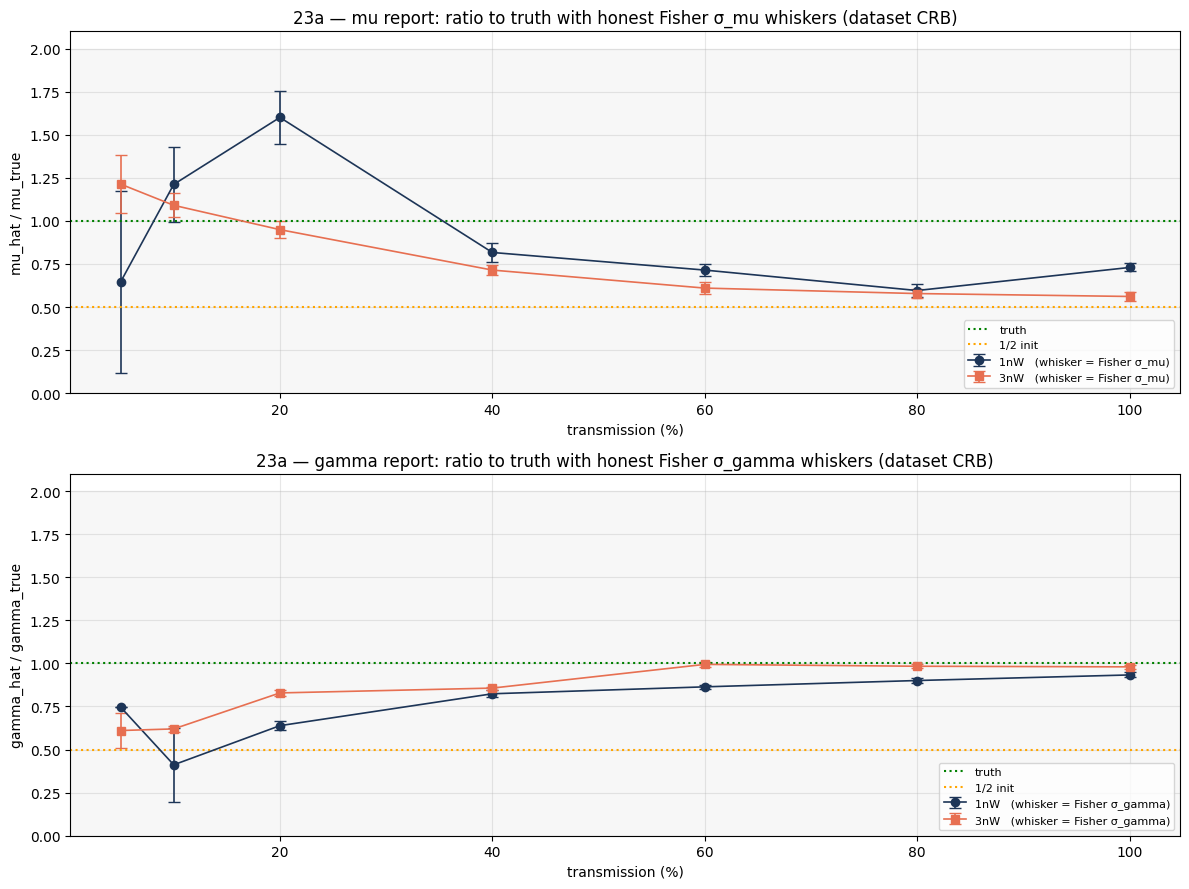

In [13]:
# ============================================================
# FIG 2 — the μ report (top) and the γ report (bottom): ratio to truth ± the Fisher CRB whisker.
#   22a's style; ONE panel per parameter, with the hue = laser power (1nW | 3nW).
#   Whisker = the dataset CRB (B): truth-inside = honesty.
# ============================================================
def _trow(power):
    return sorted([t for t in TABLE if t['exp'].startswith(power)],
                  key=lambda t: int(t['exp'].split('Trans')[-1]))

COL = {'1nW': '#1d3557', '3nW': '#e76f51'}
MK  = {'1nW': 'o-', '3nW': 's-'}
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key in zip(axes, ['mu', 'gamma']):
    for power in POWERS:
        ts = _trow(power)
        xs = [int(t['exp'].split('Trans')[-1]) for t in ts]
        if key == 'mu':
            ys  = [t['mu'] / t['mu_true'] for t in ts]
            err = [t['sig_mu_data'] / t['mu_true'] for t in ts]
        else:
            ys  = [t['gamma'] / t['gamma_true'] for t in ts]
            err = [t['sig_g_data'] / t['gamma_true'] for t in ts]
        ax.errorbar(xs, ys, yerr=err, fmt=MK[power], color=COL[power], capsize=4, ms=6, lw=1.2,
                    label=f'{power}   (whisker = Fisher σ_{key})')
    ax.axhline(1.0, color='g', ls=':', label='truth')
    ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
    ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
    ax.set_xlabel('transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'23a — {key} report: ratio to truth with honest Fisher σ_{key} whiskers (dataset CRB)')
fig.tight_layout(); plt.show()


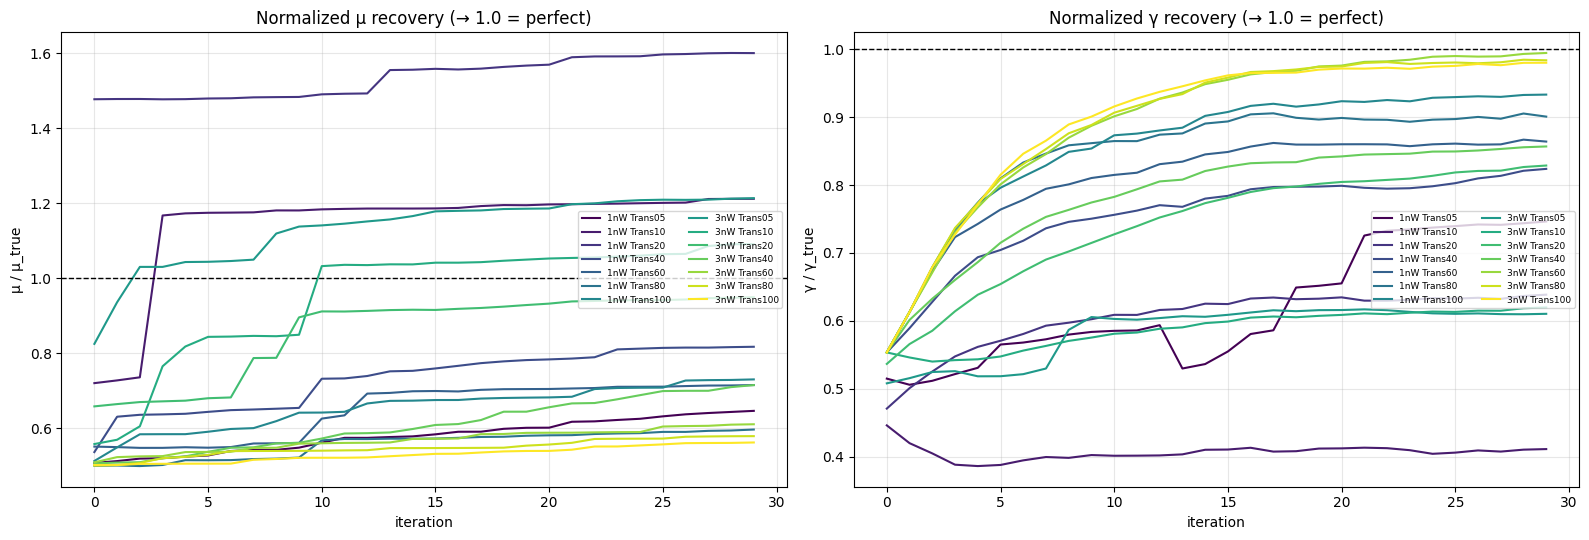

In [14]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
#   (22a verbatim)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(RESULTS)))
for r, c in zip(RESULTS, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()


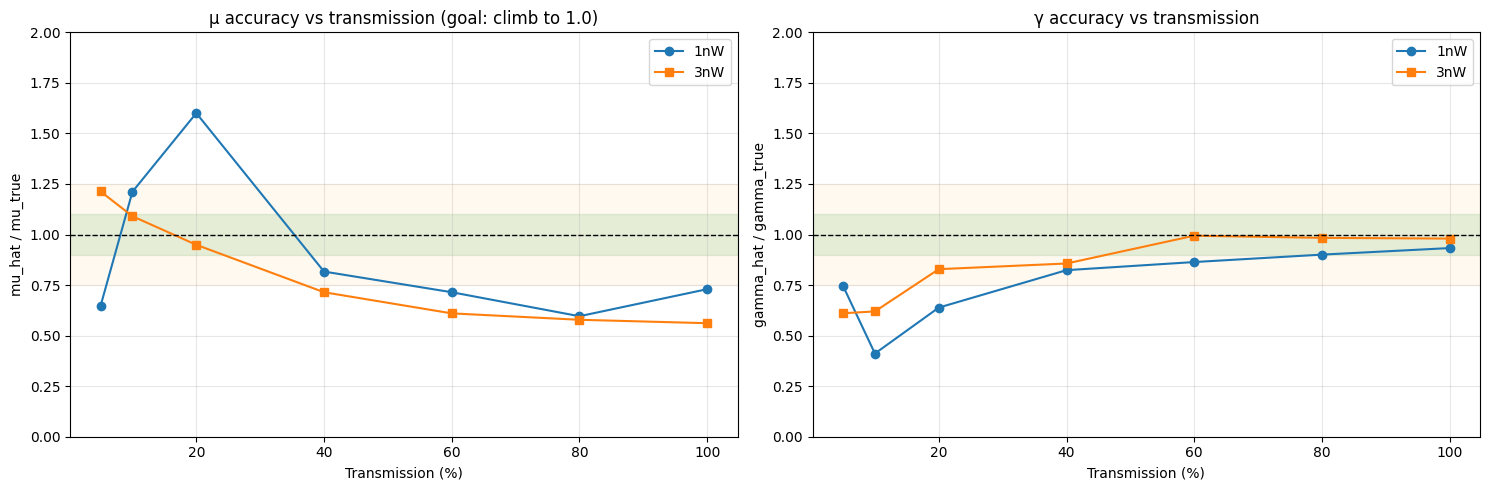

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     0.646     1.213     0.746      0.61
   10     1.212      1.09     0.411      0.62
   20       1.6     0.949     0.639     0.829
   40     0.817     0.715     0.824     0.857
   60     0.715      0.61     0.864     0.994
   80     0.596     0.578     0.901     0.983
  100      0.73     0.561     0.933      0.98


In [15]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)   (22a verbatim)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in RESULTS if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in RESULTS}):
    row = [T]
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")


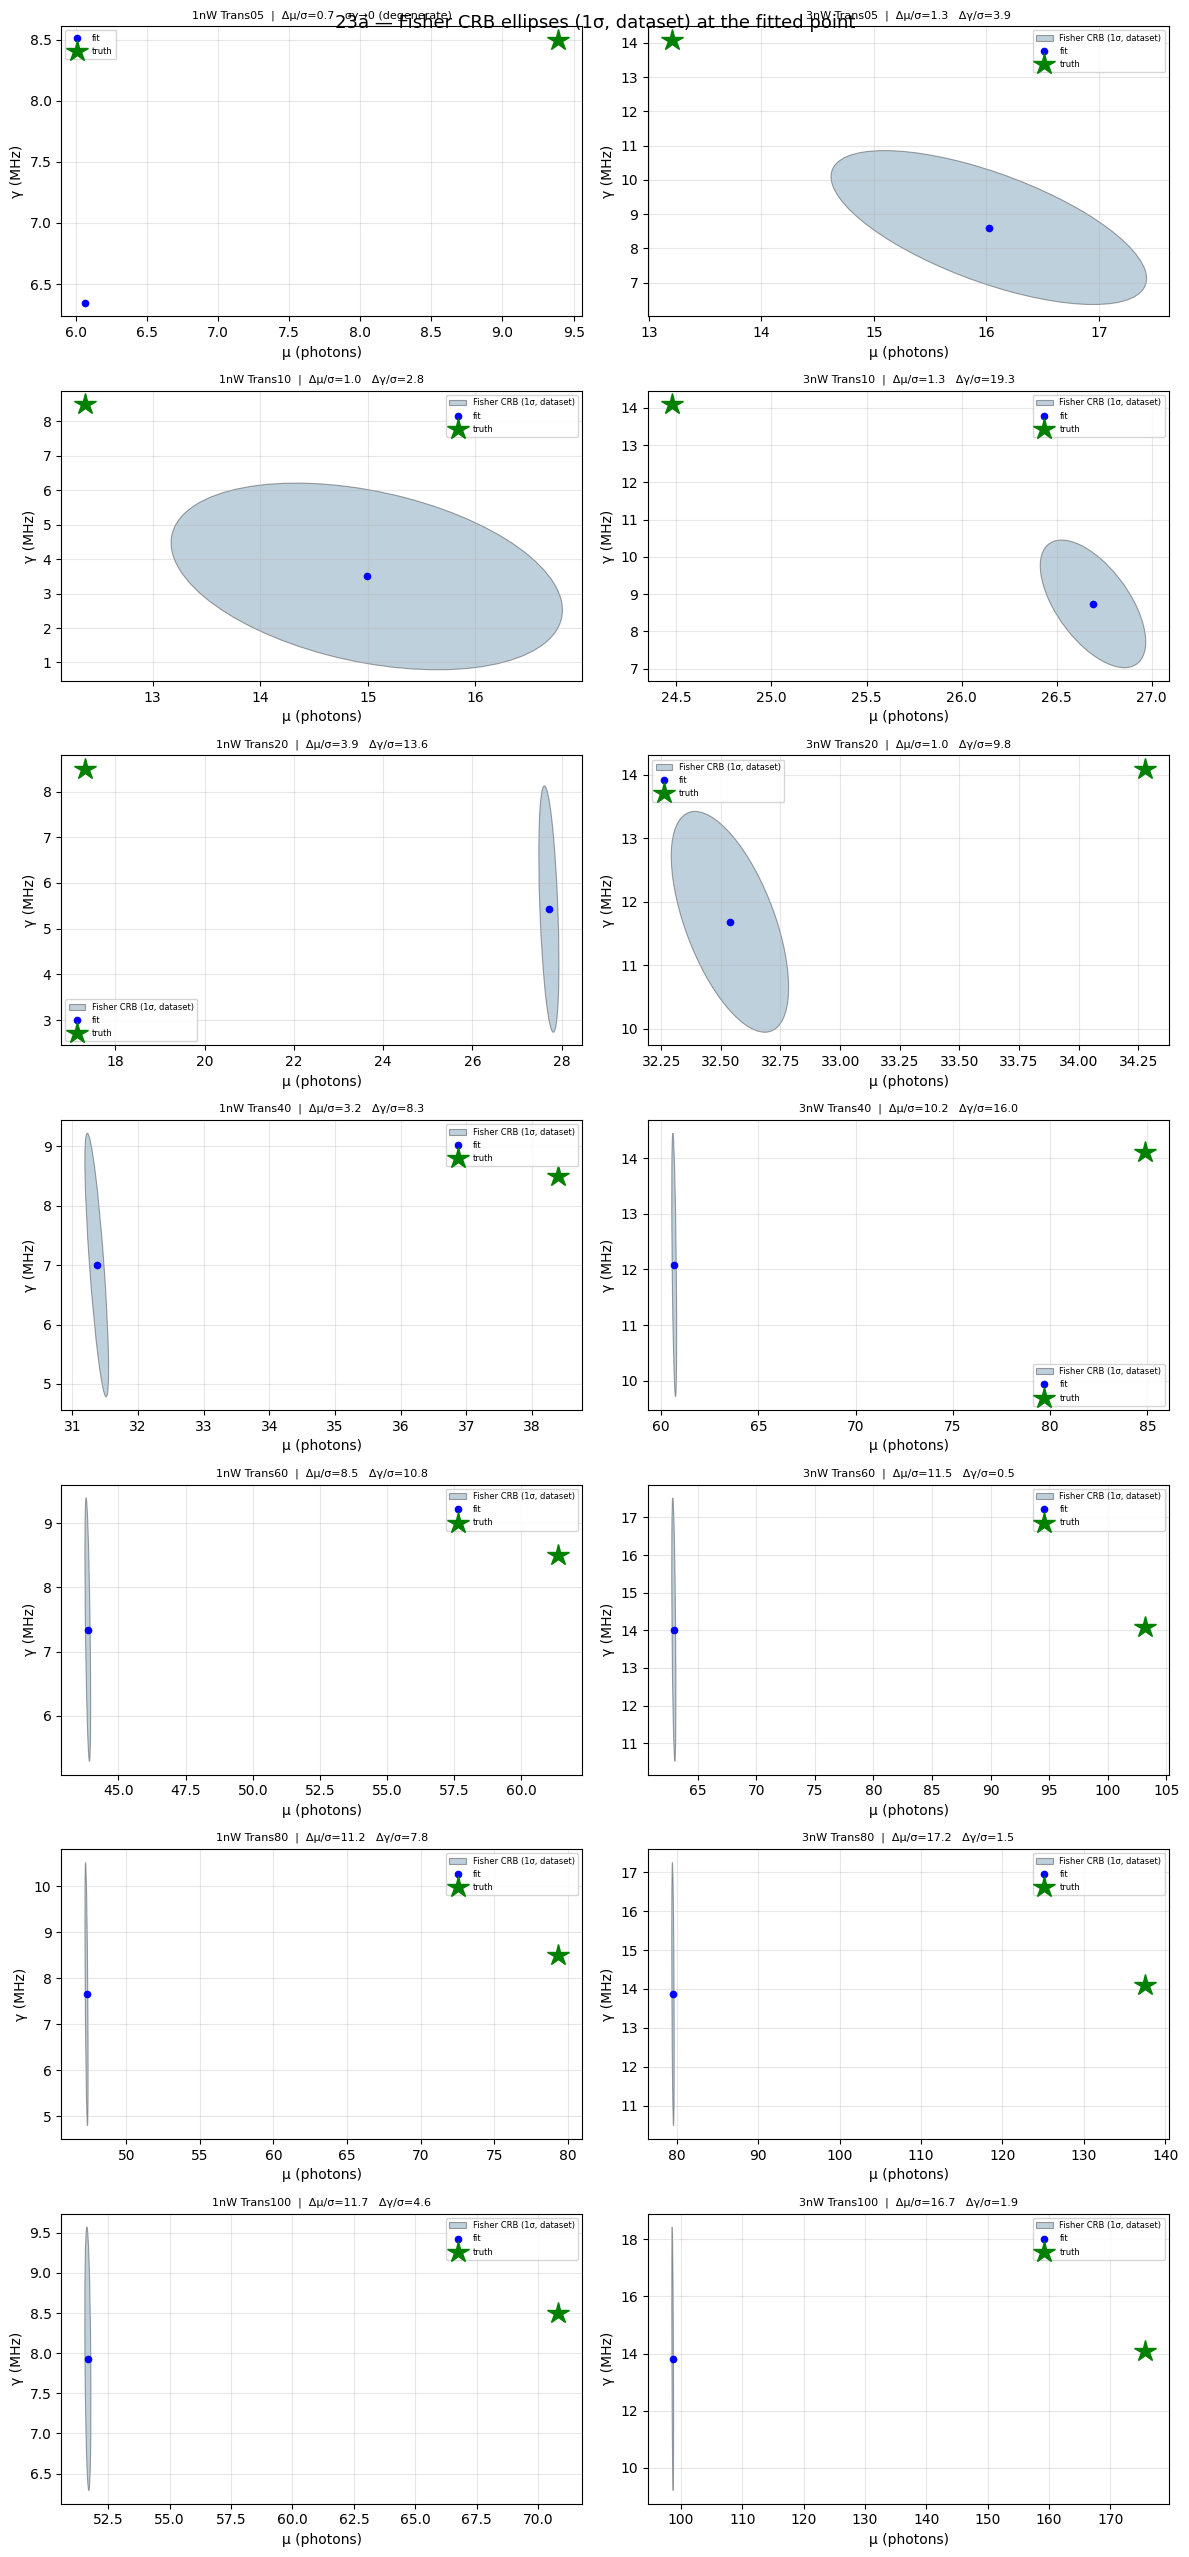

In [16]:
# ============================================================
# FIG 5 — FISHER ELLIPSES (1σ) in (μ, γ) at the fitted point
#   21c's FIG 10, laid out as 2 columns (1nW | 3nW) × 7 rows (Trans05…Trans100).
#   The ellipse is the dataset CRB (B). Variant A (per-scan) is a factor √N larger -> off-panel.
# ============================================================
from matplotlib.patches import Ellipse
fig, axes = plt.subplots(7, 2, figsize=(12, 26))
for ci, power in enumerate(POWERS):
    ts = _trow(power)
    for ri, t in enumerate(ts):
        ax = axes[ri][ci]
        sm, sg, corr = t['sig_mu_data'], t['sig_g_data'], t['corr']
        degenerate = sg < 1e-6                       # σ_γ → 0: the low-count Fisher degeneracy
        if not degenerate:
            cov = np.array([[sm**2, corr*sm*sg], [corr*sm*sg, sg**2]])
            lam_, vec = np.linalg.eigh(cov)
            ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
            ax.add_patch(Ellipse((t['mu'], t['gamma']), 2*np.sqrt(lam_[0]), 2*np.sqrt(lam_[1]),
                                 angle=ang, facecolor='#457b9d', edgecolor='k', alpha=0.35, lw=0.8,
                                 label='Fisher CRB (1σ, dataset)'))
        ax.plot(t['mu'], t['gamma'], 'b.', ms=9, label='fit')
        ax.plot(t['mu_true'], t['gamma_true'], 'g*', ms=16, label='truth')
        dg_txt = 'σγ→0 (degenerate)' if degenerate else f"Δγ/σ={t['dg_sigma_data']:.1f}"
        ax.set_title(f"{t['exp']}  |  Δμ/σ={t['dmu_sigma_data']:.1f}   {dg_txt}", fontsize=8)
        ax.set_xlabel('μ (photons)'); ax.set_ylabel('γ (MHz)'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
plt.suptitle('23a — Fisher CRB ellipses (1σ, dataset) at the fitted point', fontsize=13)
plt.tight_layout(); plt.show()


## Verdict — the CRB as we have been quoting it is honest only because it is ~√N too wide; the corrected one is not honest either, because the problem is BIAS, not variance

All 14 real experiments, frozen exp6 `trial_07`, **0 divergences**.

| variant | σ_μ range (MHz) | coverage ≤2σ (μ) | median ‖Δγ‖/σ_γ |
|---|---|---|---|
| **A** per-scan (`J = Σᵢsᵢsᵢᵀ/N`, the historic convention) | 35.7 – 231.4 | **14/14** (also 14/14 within 1σ) | 0.19 |
| **B** dataset CRB (`σ/√N`) | 1.64 – 4.61 | **5/14** (3/14 within 1σ) | 8.05 |

**(a) A "covers" only because it is enormous.** With σ_μ = 36–231 MHz against a μ error of 3–77 photons, ‖Δμ‖/σ = 0.02–0.34 → everything sits inside 1σ trivially. This is the *same family* as 19d D1's "14/14 honest": **wide but true, i.e. honest-and-uninformative**. We can now say why it was wide — it carried a **√N** factor of pure bookkeeping error.

**(b) B fails exactly where it matters.** The failures are the high-T cells (‖Δμ‖/σ = 8.5 / 11.2 / 11.7 for 1nW T60/T80/T100; 10.2 / 11.5 / 17.2 / 16.7 for 3nW T40–T100), i.e. where the μ estimate is **biased low by 27–44 %**. A Cramér–Rao bound is a *variance* bound — it **cannot cover a systematic bias** (consistent with 21j: the μ residual is bias, not variance). Perversely, σ_B *shrinks* with N while the bias stays put, so the model becomes **more confident and more wrong** exactly where the data are best.

**(c) γ shows the same pattern**: median ‖Δγ‖/σ_γ goes 0.19 (A) → 8.05 (B).

**(d) One degenerate row.** 1nW Trans05 has σ_γ → 1e-13, so its γ interval is meaningless there — the **low-count Fisher degeneracy** 19d already flagged (it hit 3nW T05 there). The ellipse is not drawn for that panel.

### What this establishes (and what is next)
- The KDE-likelihood CRB, **however normalised**, is not an honest interval for this model on this data; the binding problem is **bias, not variance**.
- Therefore the uncertainty line moves to (i) the **empirical data bootstrap** (resample the real scans — measures the actual spread and includes the bias) and (ii) **bias-aware / sandwich** intervals `J⁻¹KJ⁻¹`, valid under the misspecification we know is present (FM#8).
- A CRB can only become honest once the **σ(μ)-shape mismatch is fixed** (19d rec #2) — the uncertainty work is downstream of the point-estimate model gap.
- Caveats carried: the target is filtered (`fit_err/FWHM < 10` → selection), all scores share one MC cloud, J is an **observed** Fisher, and Scott's bandwidth rule is pathological at low T (FM#4: the 1nW T05 target has σ = 170/418 MHz).

## Notes / caveats
- **Frozen model**: exp6 `trial_07` (`sigma_weight 0.8649`, `h_f_scale 4.0`, `h_s_scale 3.6745`,
  `gamma_rel_cap 0.10736`) on the exp5 schedule. Nothing changed in `src/` or previous notebooks.
- **Likelihood**: the 2-D `(FWHM, sigma_fit)` KDE; bandwidths **fixed from the target** (rule = Scott x
  scale) -> a clean likelihood in (mu, gamma). The μ-score is the exact REINFORCE score
  (`n ~ N(mu, sigma_prop^2)`); the Fisher uses the **raw** γ chain (`GAMMA_SCALE=False`).
- **Three σ variants**: (A) the **existing per-scan** convention `J = sum_i s_i s_i^T / N`;
  (B) the **dataset CRB** `sigma/sqrt(N)`. The Scott-bandwidth variant was dropped (it conflated the
  bandwidth choice with the correction).
- **Known caveats carried in**: the target is filtered (`fit_err/FWHM < 10`) -> selection, so `N` is not
  a clean i.i.d. sample size; all `s_i` share one MC cloud (M_FINAL, averaged over FISHER_SEEDS);
  J is an **observed** (outer-product) Fisher; FM#8 means the μ-curvature comes from a mis-scaled
  σ_fit channel.
- **Figures follow 22a exactly** (same styles, same code): **FIG 1a/1b** = the interactive (μ,γ) path +
  simulated-cloud-vs-real view, one per power, with the experiment dropdown + play button + slider
  (HTML exports included); **FIG 2** = the μ report (`mu_hat/mu_true` with Fisher σ_μ whiskers) — the single
  change: **split into 1nW | 3nW**, with two whiskers per point (dataset CRB and Scott-bandwidth CRB);
  **FIG 3** = normalized trajectories; **FIG 4** = accuracy vs transmission. **FIG 5 (new)** = the 21c-style
  **Fisher CRB ellipses (1σ, dataset)** at the fitted point, laid out 2 columns (1nW | 3nW) × 7 rows
  (transparency). The report figure **FIG 2** has μ on top and γ underneath, one panel each, with the
  **hue = laser power**. Variant A (per-scan) is off-panel by design — it is √N larger. **1nW Trans05 is
  the one degenerate row** (σ_γ → 1e-13, the low-count Fisher degeneracy already flagged in 19d) — its
  ellipse is not drawn; the panel is labelled instead.
- The notebook is **cache-aware**: it loads `data/processed/23a_fisher_exp6_trial07.json` by default
  (re-render in seconds); `NB_RECOMPUTE=1` forces the full ~35 min run.
- Companion run data: `data/processed/23a_fisher_exp6_trial07.json`.